In this notebook, we present the results of assigning new patients from a different cohort of Asian origin using the previously assessed KNN algorithm. We evaluated whether any patients did not fit well into the existing system of six subphenotypes and whether it would be reasonable to propose an additional subphenotype based on their distance to the nearest cluster centroid.

In [1]:
library(yaml)
library(factoextra) # perform kmeans clustering
library(umap) # perform UMAP
library(tibble) # columns to rownames
library(umap)

Sys.setlocale("LC_ALL", "en_US.UTF-8") # for the plus_minus character

setwd("../")
source('scripts/cross_validation_utils.R')
reticulate::py_require("kaleido")
reticulate::py_require("plotly")

Loading required package: ggplot2

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



[1] "LC_CTYPE=en_US.UTF-8;LC_NUMERIC=C;LC_TIME=en_US.UTF-8;LC_COLLATE=en_US.UTF-8;LC_MONETARY=en_US.UTF-8;LC_MESSAGES=en_US.UTF-8;LC_PAPER=en_US.UTF-8;LC_NAME=C;LC_ADDRESS=C;LC_TELEPHONE=C;LC_MEASUREMENT=en_US.UTF-8;LC_IDENTIFICATION=C"


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: lattice


Attaching package: ‘kknn’


The following object is masked from ‘package:caret’:

    contr.dummy



Attaching package: ‘plotly’


The following object is masked from ‘package:ggplot2’:

    last_plot


The following object is masked from ‘package:stats’:

    filter


The following object is masked from ‘package:graphics’:

    layout




Using virtual environment '/home/ines/.virtualenvs/r-reticulate' ...


+ /home/ines/.virtualenvs/r-reticulate/bin/python -m pip install --upgrade --no-user 'kaleido==0.2.1'



In [2]:
# Load the configuration file
config <- yaml::yaml.load_file("config.yml")

knn_neighbors <- config$clustering_cross_validation$n_nearst_neighbours
set_seed <- config$clustering_cross_validation$random_state
cluster_palette <- config$colors$cluster

In [3]:
output_path <- "outputs/clustering_analysis/korean_population/"
# Create the output directory if it does not exist
if (!dir.exists(output_path)) {
  dir.create(output_path, recursive = TRUE)
}

In [4]:
# Load data

# Load the landmark coordinates data
df_coordinates <- read.csv(config$dataset$landmark_coordinates, check.names = FALSE, row.names = 1)


# Load Korean population data
df_coordinates_korean_1 <- read.csv(config$dataset$landmark_coordinates_korean, check.names = FALSE, row.names = 1)
# include additional patients with korean origin
df_coordinates_korean_2 <- read.csv("data/korean_2/df_coordinates.csv", check.names = FALSE, row.names = 1)

In [5]:
# check for duplicates!
df_korean_merged <- rbind(df_coordinates_korean_1, df_coordinates_korean_2)
print(dim(df_korean_merged))

[1] 202  24


In [6]:
df_korean_merged[duplicated(df_korean_merged), ]

,X_Sella,Y_Sella,X_Basion,Y_Basion,X_PNS,Y_PNS,X_A Point,Y_A Point,X_B Point,Y_B Point,⋯,X_Gonion,Y_Gonion,X_Ramus Point,Y_Ramus Point,X_Distal Aspect of Condyle,Y_Distal Aspect of Condyle,X_Condylion,Y_Condylion,X_Nasion,Y_Nasion
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KM3-001,0,0,-19.3,-35.5,18.6,-38.0,55.8,-43.8,63.8,-73.8,⋯,2.2,-69.5,-4.5,-57.5,-11.6,-22.5,-8.2,-17.8,54.4,7.8
KM3-002,0,0,-21.1,-37.6,21.3,-45.9,64.9,-52.5,72.1,-98.9,⋯,2.4,-81.1,-5.9,-56.3,-14.1,-27.0,-9.9,-20.2,64.7,5.3
KM3-003,0,0,-21.0,-37.1,15.8,-46.4,53.5,-50.9,55.7,-93.7,⋯,-8.3,-82.9,-12.9,-65.1,-13.4,-26.7,-8.7,-20.3,56.8,5.5
KM3-004,0,0,-23.8,-40.7,22.6,-46.7,63.6,-52.8,68.5,-95.8,⋯,-1.0,-84.3,-7.8,-68.5,-15.9,-29.7,-10.9,-22.4,70.1,3.8
KM3-005,0,0,-25.4,-36.3,15.2,-43.3,58.1,-46.2,68.5,-79.4,⋯,-2.0,-75.9,-7.4,-62.7,-19.8,-23.6,-14.8,-17.2,57.8,11.4
KM3-006,0,0,-22.6,-31.2,16.5,-39.2,54.5,-40.4,59.6,-80.5,⋯,-2.8,-67.3,-8.0,-53.4,-13.3,-20.4,-9.7,-16.3,54.6,11.8
KM3-008,0,0,-17.6,-39.7,22.0,-41.6,64.2,-43.2,67.3,-90.9,⋯,4.5,-80.8,-0.6,-65.5,-12.6,-22.5,-6.9,-16.6,57.5,10.6
KM3-009,0,0,-29.4,-33.5,16.7,-40.2,61.0,-49.0,66.0,-91.2,⋯,-6.5,-75.1,-11.8,-60.9,-17.2,-21.7,-12.3,-17.9,61.7,9.3
KM3-010,0,0,-26.6,-35.9,17.1,-40.8,54.0,-43.1,62.5,-81.5,⋯,-0.6,-69.2,-5.8,-57.9,-14.6,-21.0,-11.6,-16.0,58.1,12.5


In [7]:
sum(duplicated(df_korean_merged))

[1] 16

In [8]:
# remove duplicates
df_coordinates_korean <- df_korean_merged[!duplicated(df_korean_merged), ]
print(dim(df_korean_merged))

[1] 202  24


Training - Caucasian dataset

In [9]:
# Training ....
# Apply the GPA and the clustering k = 6
training <- get_training_clusters(df_coordinates, 'tan', fun_cluster = 'kmean', k = 6, hc_metric = "euclidean")

Testing - Korean dataset

In [10]:
# Testing ....
# Perform the OPA and the KNN
testing <- get_testing_clusters(df = df_coordinates_korean, gpa = training$gpa, type = 'tan',
                        set_seed = set_seed,  knn_params = list(k=knn_neighbors), X_train = training$gpa$tan,
                        y_train = training$cluster)

# Korean population and assigned clusters

## UMAP representation

In [11]:
# Compute the centroids of the training clusters
centroid_df <- data.frame(cbind(training$train_data, cluster = factor(training$cluster))) %>%
  group_by(cluster) %>%
  summarise(across(everything(), \(x) mean(x, na.rm = TRUE))) %>%
  column_to_rownames(var = "cluster")
centroid_df

,X_Sella,X_Basion,X_PNS,X_A.Point,X_B.Point,X_Pogonion,X_Menton,X_Gonion,X_Ramus.Point,X_Distal.Aspect.of.Condyle,⋯,Y_PNS,Y_A.Point,Y_B.Point,Y_Pogonion,Y_Menton,Y_Gonion,Y_Ramus.Point,Y_Distal.Aspect.of.Condyle,Y_Condylion,Y_Nasion
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.082547232,-0.1366501,0.9000226,2.555053,-0.7113360,0.1846690,0.08985951,-1.856868,-3.898349,-0.8872158,⋯,-0.02418366,-1.348073,1.9654458,3.374835169,2.8329272,-4.4557544,-0.8539405,-0.8592060,-0.9596781,-1.5227744
2,-0.001668214,2.6156876,2.1174821,2.207547,-1.6545934,-1.8073664,-1.86528250,-1.523161,-1.112141,0.7686187,⋯,1.09656979,1.783596,-1.5368630,-0.694775113,-0.3173928,-0.5681628,0.8102839,-2.8511546,-2.0679464,5.3728791
3,0.001663807,-4.3942088,-1.7058866,-2.223419,2.3649516,1.0447787,0.80581385,2.372962,1.907521,-0.5917012,⋯,-0.88546860,-1.552543,1.7833141,0.001854623,0.2314830,1.5218067,-1.4690342,3.7477827,2.2957002,-4.7491510
4,-0.551607015,-0.4451398,0.7688205,1.679910,0.8185387,1.7080466,1.95731159,-3.508259,-1.264878,-0.6496220,⋯,-0.72351345,-1.349047,-1.3650730,0.769795255,0.4983006,4.1043923,4.4844036,-2.1130713,-1.0903968,-1.3214107
5,-0.941288516,2.5922719,-0.5109172,-2.299692,-0.2747726,-0.3508302,0.04755683,1.082428,2.488186,0.7886204,⋯,0.38858843,1.416037,-1.3249883,-2.774842832,-2.6350157,1.5698972,-0.7168292,0.2142622,0.6669259,2.2919039
6,-0.010490344,-0.5088789,-4.0492850,-6.225721,-0.3859474,-1.6676933,-2.09188749,8.686555,6.971321,1.7866886,⋯,0.29117814,3.041712,-0.2175989,-4.012958533,-3.4654526,-1.1961624,-4.4843033,4.9019693,3.3911136,0.6382125


In [12]:
# Compute the UMAP coordinates reduction for 2 dimensions
residuals_train <- training$gpa$tan
residuals_test <- testing$test_data

# Train UMAP model on the initial dataset
umap_model <- umap(residuals_train, n_components = 2, random_state = 15)
X_train_umap <- as.data.frame(umap_model$layout)
X_train_umap$cluster <- training$cluster
X_train_umap$label <- "Caucasian"

# Transform new dataset
X_external_umap <- as.data.frame(predict(umap_model, residuals_test))
X_external_umap$label <- "Korean"
X_external_umap$cluster <- testing$cluster

# Transform UMAP (centroid)
X_centroid_umap <- as.data.frame(predict(umap_model, centroid_df))

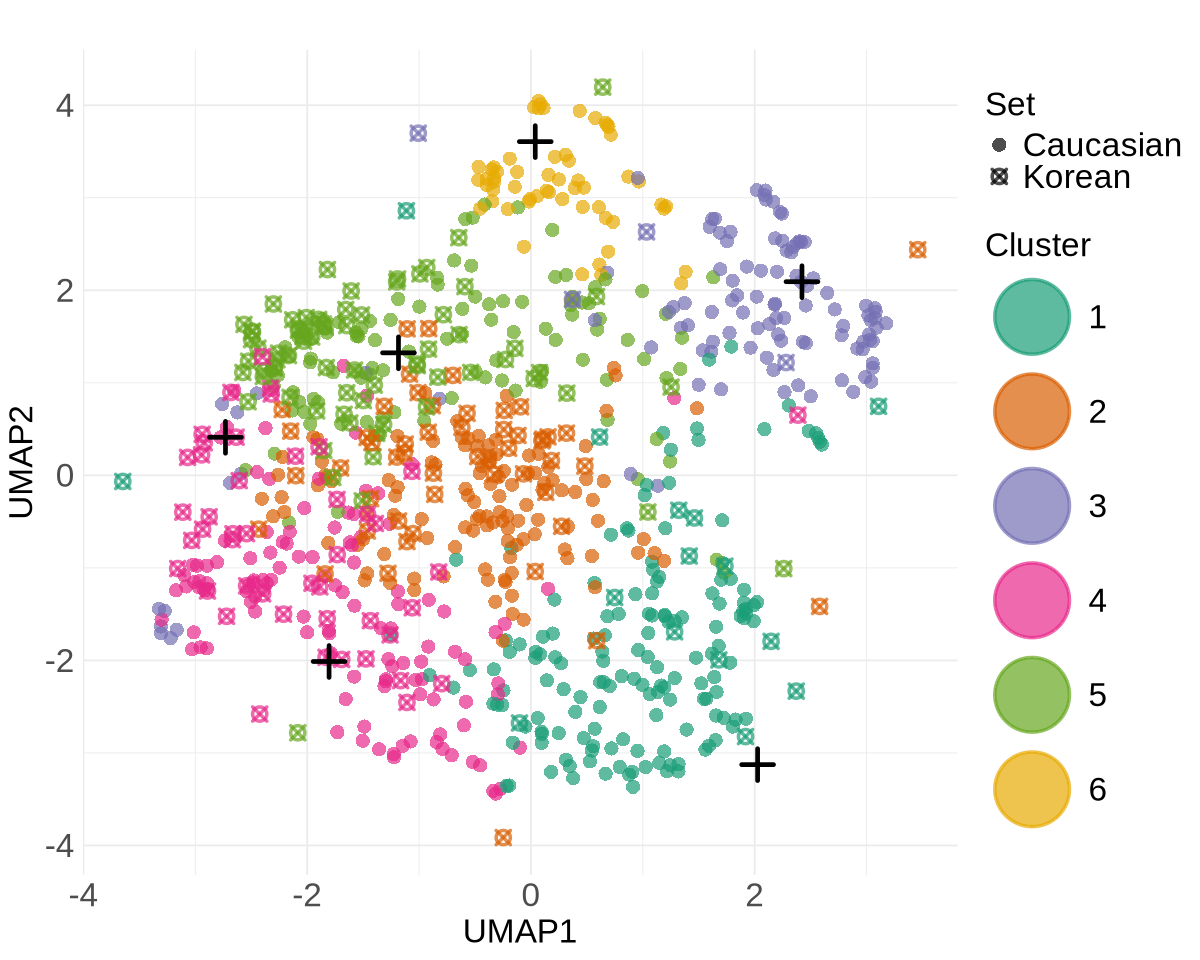

In [13]:
options(repr.plot.width=10, repr.plot.height=8)
# Plot the UMAP results
# Combine both datasets
umap_results <- rbind(X_train_umap, X_external_umap)
colnames(umap_results)[1:2] <- c("UMAP1", "UMAP2")  # Rename columns

# Generate the UMAP plot
umap_cluster_plot <- ggplot(umap_results, aes(x = UMAP1, y = UMAP2, color = factor(cluster), shape = factor(label))) +
  geom_point(alpha = 0.7, size = 3, stroke = 1.5) +
  scale_color_manual(values = cluster_palette) +
  scale_shape_manual(values = c("Caucasian" = 16, "Korean" = 13, centroid = 3)) +
  geom_point(data = X_centroid_umap, aes(x = V1, y = V2), color = "black", size = 5, shape = 3, stroke=2) +
  labs(title = "", #"UMAP Projection of Training and New Data",
       color = "Cluster",
       shape =  "Set") +
  theme_minimal() +
  theme(legend.position = "right",
      legend.title = element_text(size = 20),
      legend.text = element_text(size = 20),
      plot.title = element_text(hjust = 0.5, size = 20),
      axis.title.x = element_text(size = 20),
      axis.title.y = element_text(size = 20),
      axis.text.x = element_text(size = 20),
      axis.text.y = element_text(size = 20)) +
  guides(color=guide_legend(override.aes=list(size=20)))

ggsave(filename = paste0(output_path, "umap_clusters.png"),
       plot = umap_cluster_plot,
       width = 10, height = 7, dpi = 300)

umap_cluster_plot

## Clusters distributions

In [14]:
# Create a summary table with the counts and percentages of each cluster
df_korean_summary <- data.frame(Cluster = testing$cluster) %>% group_by(Cluster) %>% summarise(
    Count = n(),
    `Percentage (%)` = round(n() / nrow(df_coordinates_korean) * 100, 2)
)

write.csv(df_korean_summary, paste(output_path, 'korean_summary_distribution.csv'), row.names = TRUE)

df_korean_summary

Cluster,Count,Percentage (%)
<fct>,<int>,<dbl>
1,15,8.06
2,51,27.42
3,4,2.15
4,45,24.19
5,71,38.17


## Assess distance to clusters centroids

In [15]:
# Compute distance from each point of training data to its assigned cluster centroid
centroid_distances_training_data <- mapply(function(i, cluster) {
  euclidean_distance(training$train_data[i, ], centroid_df[as.character(cluster), ])
}, i = seq_len(nrow(training$train_data)), cluster = training$cluster)

# Compute distance from each point in korean population (testing data) to its assigned cluster centroid
centroid_distances_korean <- mapply(function(i, cluster) {
  euclidean_distance(testing$test_data[i, ], centroid_df[as.character(cluster), ])
}, i = seq_len(nrow(testing$test_data)), cluster = testing$cluster)

# Create a data frame with the distances and cluster assignments
df_distances <- rbind(
  data.frame(Distance = centroid_distances_training_data, Cluster = paste('Cluster',training$cluster), Set = "Caucasian", row.names = rownames(training$train_data)),
  data.frame(Distance = centroid_distances_korean, Cluster = paste('Cluster', testing$cluster), Set = "Korean", row.names = rownames(testing$test_data))
)

head(df_distances)

,Distance,Cluster,Set
,<dbl>,<chr>,<chr>
CT-001,14.520628,Cluster 3,Caucasian
CT-002,9.130315,Cluster 5,Caucasian
CT-003,12.063372,Cluster 3,Caucasian
CT-004,11.019151,Cluster 3,Caucasian
CT-005,14.564043,Cluster 5,Caucasian
CT-006,13.723453,Cluster 5,Caucasian


### Density distance distributions: training data vs. korean population

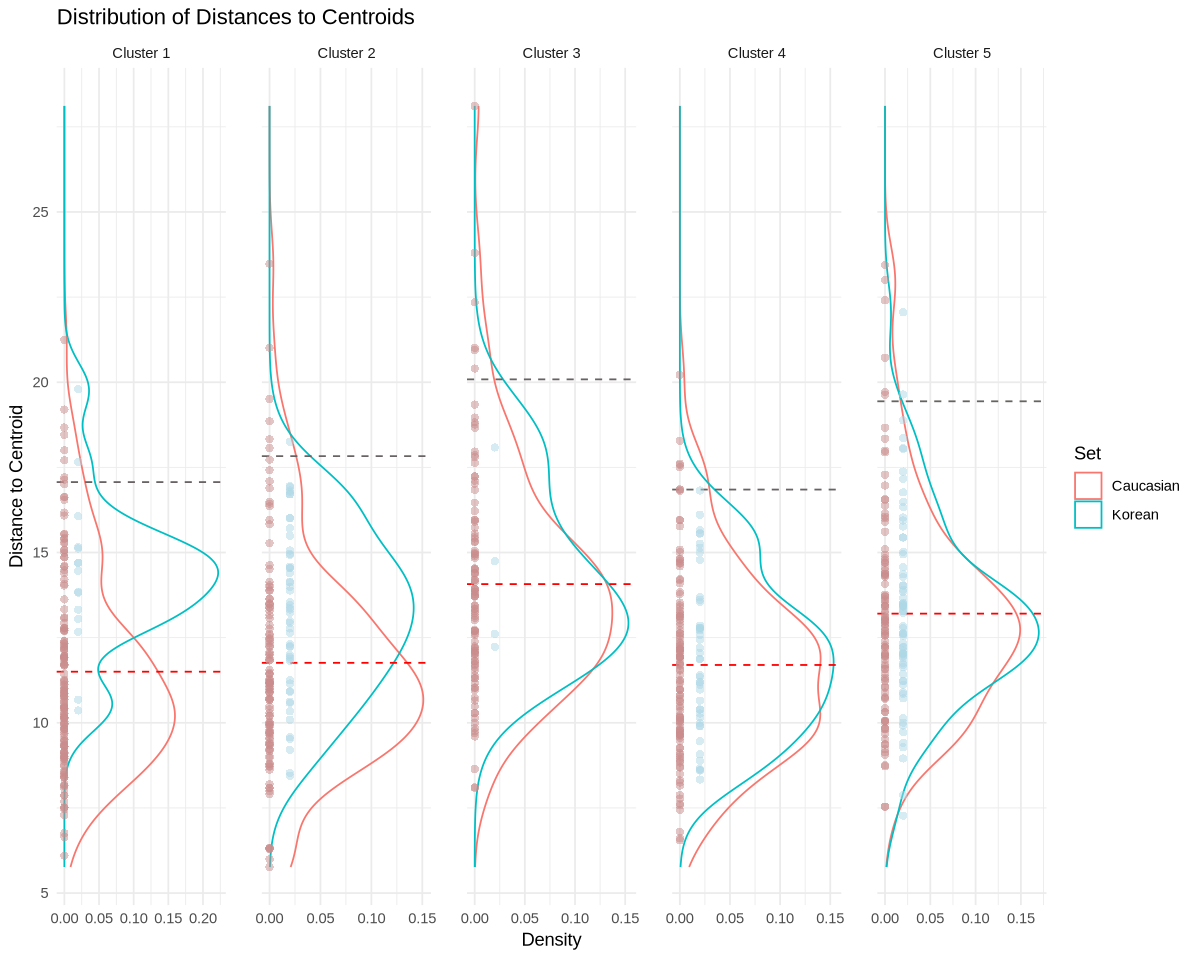

In [16]:
#options(repr.plot.width=5, repr.plot.height=10)
options(repr.plot.width=10, repr.plot.height=8)
#options(repr.plot.width=10, repr.plot.height=4)
filtered_distances <- df_distances %>% filter(Cluster != 'Cluster 6')
# Plot the distribution of distances to centroids
distance_distribution_plot <- ggplot(filtered_distances, aes(x = Distance, color = Set)) +
  geom_density() +
  facet_wrap(Cluster~., ncol = 5, scales = "free_x") +
  # Include a vertical line at the mean distance # mean(Distance) + quantile(Distance, 0.95)
  geom_vline(data = filtered_distances %>% filter(Set == 'Caucasian') %>% group_by(Cluster) %>% summarise(mean_distance = mean(Distance)), aes(xintercept = mean_distance), linetype = "dashed", color = "red") +
  geom_vline(data = filtered_distances %>% filter(Set == 'Caucasian') %>% group_by(Cluster) %>% summarise(sd = quantile(Distance, 0.95)), aes(xintercept = sd), linetype = "dashed", color = "#686262") +
  geom_point(data = filtered_distances %>% filter(Set == 'Korean') %>% group_by(Cluster), aes(x = Distance, y = 0.02), color = "lightblue", size = 2, shape = 16, alpha = 0.5) +
     geom_point(data = filtered_distances %>% filter(Set == 'Caucasian') %>% group_by(Cluster), aes(x = Distance, y = 0), color = "#c98b8b", size = 2, shape = 16, alpha = 0.5) +
     
  labs(title = "Distribution of Distances to Centroids",
       x = "Distance to Centroid",
       y = "Density",
       color = "Set") +
  theme_minimal() +
  theme(legend.position = "right",
    panel.spacing.x = unit(1.5, "lines")  # or "cm", "pt", "mm", etc.
  ) +
   coord_flip()

# Save the plot
ggsave(filename = paste0(output_path, "distance_distribution.pdf"),
       plot = distance_distribution_plot,
       width = 10, height = 3, dpi = 300)

distance_distribution_plot

### Compare distance distributions with Wilcoxon test

In [17]:
# Wilcoxon test to compare the distributions of distances
df_distances %>% group_by(Cluster) %>% filter(n_distinct(Set) > 1) %>%
summarise(
    p_value = ifelse(shapiro.test(Distance)$p.value > 0.05,  # Normality test
                     t.test(Distance ~ Set, var.equal = TRUE)$p.value,  # Use t-test if normal
                     wilcox.test(Distance ~ Set)$p.value)  # Use Wilcoxon if not normal
  ) %>%
  mutate(
    p_adj = p.adjust(p_value, method = "BH"),  # Benjamini-Hochberg correction
    significant = p_adj < 0.05
  )
# p < 0.05 → Significant difference

Cluster,p_value,p_adj,significant
<chr>,<dbl>,<dbl>,<lgl>
Cluster 1,0.0002716238,0.001088073,TRUE
Cluster 2,0.0004352292,0.001088073,TRUE
Cluster 3,0.6982842955,0.698284295,FALSE
Cluster 4,0.3543562233,0.590593705,FALSE
Cluster 5,0.5404214077,0.675526760,FALSE


### Assess Outilers based on distance to the centroid

In [18]:
# Compute distance metric (mean, std, mean + 2.5std, quantile) for the training set per cluster 
df_distance_metrics_training  <- df_distances %>% filter(Set == 'Caucasian') %>%
  group_by(Cluster) %>%
  summarise(
    Count = n(),
    `Mean Distance` = mean(Distance),
    `Standard Deviation` = sd(Distance),
    `2.5 SD` = mean(Distance) + 2 * sd(Distance),
    `Quantile 0.95` = quantile(Distance, 0.95),
  )
  df_distance_metrics_training

Cluster,Count,Mean Distance,Standard Deviation,2.5 SD,Quantile 0.95
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Cluster 1,152,11.50032,2.887388,17.27509,17.06737
Cluster 2,115,11.76058,3.186051,18.13268,17.83042
Cluster 3,107,14.07285,3.329989,20.73283,20.08442
Cluster 4,118,11.69753,2.693721,17.08497,16.84847
Cluster 5,105,13.20488,3.158456,19.52179,19.43989
Cluster 6,58,15.75146,4.311325,24.37411,21.58042


In [19]:
# Present outliers based on patients having a distance greater than 2.5 standard deviations from the mean
df_distances %>% filter(Set == 'Korean') %>%
    rownames_to_column(var = "Patient") %>%
    left_join(df_distance_metrics_training, by = "Cluster") %>%
    mutate(Outlier = ifelse(Distance > `2.5 SD`, "Outlier", "Non-Outlier")) %>%
    filter(Outlier == "Outlier")

Patient,Distance,Cluster,Set,Count,Mean Distance,Standard Deviation,2.5 SD,Quantile 0.95,Outlier
<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
KM3-13,17.65944,Cluster 1,Korean,152,11.50032,2.887388,17.27509,17.06737,Outlier
KM3-41,18.24845,Cluster 2,Korean,115,11.76058,3.186051,18.13268,17.83042,Outlier
KM1-039,19.79416,Cluster 1,Korean,152,11.50032,2.887388,17.27509,17.06737,Outlier
KM1-054,19.64140,Cluster 5,Korean,105,13.20488,3.158456,19.52179,19.43989,Outlier
KM3-106,22.05316,Cluster 5,Korean,105,13.20488,3.158456,19.52179,19.43989,Outlier


In [20]:
# Present outliers based on patients having a distance greater than the 95th quantile
outliers_q_95 <- df_distances %>% filter(Set == 'Korean') %>%
    rownames_to_column(var = "Patient") %>%
    left_join(df_distance_metrics_training, by = "Cluster") %>%
    mutate(Outlier = ifelse(Distance > `Quantile 0.95`, "Outlier", "Non-Outlier")) %>%
    filter(Outlier == "Outlier")
outliers_q_95

Patient,Distance,Cluster,Set,Count,Mean Distance,Standard Deviation,2.5 SD,Quantile 0.95,Outlier
<chr>,<dbl>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
KM3-13,17.65944,Cluster 1,Korean,152,11.50032,2.887388,17.27509,17.06737,Outlier
KM3-41,18.24845,Cluster 2,Korean,115,11.76058,3.186051,18.13268,17.83042,Outlier
KM1-039,19.79416,Cluster 1,Korean,152,11.50032,2.887388,17.27509,17.06737,Outlier
KM1-054,19.64140,Cluster 5,Korean,105,13.20488,3.158456,19.52179,19.43989,Outlier
KM3-106,22.05316,Cluster 5,Korean,105,13.20488,3.158456,19.52179,19.43989,Outlier


In [21]:
# Ensure ClusterNumber is numeric
outliers_q_95 <- outliers_q_95 %>% mutate(ClusterNumber = as.numeric(gsub("Cluster ", "", Cluster)))

# Loop over each row
for (i in seq_len(nrow(outliers_q_95))) {
  cluster_number <- outliers_q_95$ClusterNumber[i]
  patient_id    <- outliers_q_95$Patient[i]
  
  ##Make mshape + outliers plot
  # Compute mean shape of the cluster
  cluster_mshape <- apply(training$gpa$rotated[, , training$cluster == cluster_number], c(1, 2), mean)
  dimnames(cluster_mshape) <- list(config$selected_landmark, c("x", "y"))
  
  # Get patient shape
  patient_shape <- testing$opa$rotated[, , patient_id]
  
  # Plot the shapes
  plot <- plot_mshapes(
    shapes = list(cluster_mshape, patient_shape),
    color = c(cluster_palette[[cluster_number]], "black"),
    shape_labels = c(paste0("Cluster ", cluster_number), patient_id),
    joinlines = get_anatomical_lines(config),
    line_width = 3
  ) %>%
    layout(
      title = paste0("Cluster ", cluster_number, " VS. ", patient_id),
      font = list(size = 14),
      margin = list(t = 35)
    )
  
  # Add SD polygons for the cluster
  plot <- add_sd_polygons(plot, training$gpa$rotated[, , training$cluster == cluster_number])
  
  # Save SVG
  save_image_svg(
    p = plot,
    output_path = paste0(output_path, patient_id, "_cluster_", cluster_number, ".svg"),
    width = 500,
    height = 500
  )
}


In [22]:
# Probability of belonging to each cluster
t(testing$probability[outliers_q_95$Patient, ])

,KM3-13,KM3-41,KM1-039,KM1-054,KM3-106
1,0.76,0.00,0.68,0.00,0.00
2,0.00,0.76,0.20,0.00,0.00
3,0.04,0.00,0.00,0.04,0.08
4,0.16,0.00,0.00,0.00,0.12
5,0.04,0.24,0.04,0.56,0.44
6,0.00,0.00,0.08,0.40,0.36


# Korean VS. Caucasian Shape cluster

In [23]:
plot_list <- list()
for (c in sort(unique(testing$cluster))) {
    # Filtered testing$opa$rotated
    not_keep_idx <- which(dimnames(testing$opa$rotated)[[3]] %in% outliers_q_95$Patient)
    filtered_testing_opa_rotated <- testing$opa$rotated[, ,-not_keep_idx]
    filtered_testing_cluster <- testing$cluster[-not_keep_idx]
    cluster_mshape_training <- apply(training$gpa$rotated[, , training$cluster == c], c(1, 2), mean)
    cluster_mshape_testing <- apply(filtered_testing_opa_rotated[, , filtered_testing_cluster  == c], c(1, 2), mean)
    
    # Plot the shapes
    plot <- plot_mshapes(shapes = list(cluster_mshape_training, cluster_mshape_testing),
        color = c(cluster_palette[[c]], "black"),
        shape_labels = c("Cluster Training", "Cluster  Testing"),
        joinlines = get_anatomical_lines(config),
        line_width = 3,
        width = 500,
        height = 500
    ) %>%
    layout(title = paste('Cluster ', c, ': Caucasian VS. Korean', sep=''), font = list(size = 14), margin = list(t = 35))

    # Include sd polygons
    plot <- add_sd_polygons(plot, training$gpa$rotated[, , training$cluster == c], fill_color = "rgba(128, 18, 12, 0.3)")  # Caucasian dataset
    plot <- add_sd_polygons(plot, filtered_testing_opa_rotated[, , filtered_testing_cluster == c], fill_color = "rgba(128, 128, 128, 0.3)")  # Korean dataset

    # Save the plot
    plot_list[[c]] <- plot
    save_image_svg(p=plot, output_path = paste0(output_path, "cluster_", c, ".svg"), width = 500, height = 500)
}